In [1]:
# Library for dataframe reading
import pandas as pd

# Library for visualizations 
import seaborn as sns

# Library for SQL queries
import getpass

import pg8000


In [2]:
# connecting to the database 
login = input('Login username: ')
secret = getpass.getpass()

credentials = {'user'    : login,
               'password': secret, 
               'database': 'csci403',
               'host'    : 'ada.mines.edu'}

db = pg8000.connect(**credentials)

cursor = db.cursor()

In [3]:
# DATA EXPLORATION: what is the average trip duration for each start and end station pair in the dataset?

# NOTE: before performing the data aggregation, there was a view created to obtain a 
# subset of the data (see in queries.sql)

# perform data aggregation
average_trip_query = """
SELECT start_lat,
start_lng,
end_lat,
end_lng,
usertype,
st_month,
st_hour,
ed_hour,
gender,
start_dpcapactiy,
end_dpcapacity ,
       AVG(trip_duration)
FROM subset_trip
WHERE usertype IS NOT NULL
AND st_month IS NOT NULL
AND ed_hour IS NOT NULL
AND start_dpcapactiy IS NOT NULL
AND end_dpcapacity IS NOT NULL 
AND gender <> -1
GROUP BY start_lat, start_lng, end_lat, end_lng, usertype, st_month, st_hour, ed_hour, start_dpcapactiy,  end_dpcapacity, gender


"""
cursor.execute(average_trip_query)

# fetch results from aggregation
average_trip = cursor.fetchall()

In [4]:
# convert list to visual dataframe (Easier for reading exact data)
average_trip = pd.DataFrame(average_trip, columns=["start_lat","start_lng","end_lat","end_lng","usertype","st_month","st_hour","ed_hour","gender","start_dpcapactiy","end_dpcapactiy","avg_trip_duration"])

In [5]:
# converting avg to a numeric column
average_trip.info()
average_trip["avg_trip_duration"] = pd.to_numeric(average_trip['avg_trip_duration'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44453 entries, 0 to 44452
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   start_lat          44453 non-null  float64
 1   start_lng          44453 non-null  float64
 2   end_lat            44453 non-null  float64
 3   end_lng            44453 non-null  float64
 4   usertype           44453 non-null  int64  
 5   st_month           44453 non-null  int64  
 6   st_hour            44453 non-null  int64  
 7   ed_hour            44453 non-null  int64  
 8   gender             44453 non-null  int64  
 9   start_dpcapactiy   44453 non-null  int64  
 10  end_dpcapactiy     44453 non-null  int64  
 11  avg_trip_duration  44453 non-null  object 
dtypes: float64(4), int64(7), object(1)
memory usage: 4.1+ MB


In [6]:
# Checking to see if conversion was successful
average_trip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44453 entries, 0 to 44452
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   start_lat          44453 non-null  float64
 1   start_lng          44453 non-null  float64
 2   end_lat            44453 non-null  float64
 3   end_lng            44453 non-null  float64
 4   usertype           44453 non-null  int64  
 5   st_month           44453 non-null  int64  
 6   st_hour            44453 non-null  int64  
 7   ed_hour            44453 non-null  int64  
 8   gender             44453 non-null  int64  
 9   start_dpcapactiy   44453 non-null  int64  
 10  end_dpcapactiy     44453 non-null  int64  
 11  avg_trip_duration  44453 non-null  float64
dtypes: float64(5), int64(7)
memory usage: 4.1 MB


In [7]:
# DATA EXPLORATION: what is the average trip duration by gender?

avg_trip_gender_query = """
SELECT start_station_name,
gender,
end_station_name,
       AVG(trip_duration)
FROM subset_trip
WHERE end_station_name IS NOT NULL 
AND start_station_name IS NOT NULL
AND gender <> -1
GROUP BY gender,start_station_name, end_station_name
ORDER BY end_station_name
                        """
cursor.execute(avg_trip_gender_query)

average_trip_gender = cursor.fetchall()

average_trip_gender = pd.DataFrame(average_trip_gender, columns=["start_location","gender","end_location","avg_trip_duration"])
average_trip_gender["avg_trip_duration"] = pd.to_numeric(average_trip_gender['avg_trip_duration'])

In [8]:
average_trip_gender.head()

,start_location,gender,end_location,avg_trip_duration
0,Dearborn St & Erie St,1,900 W Harrison St,977.000000
1,Canal St & Madison St,1,900 W Harrison St,564.000000
2,Clinton St & Washington Blvd,0,900 W Harrison St,506.000000
3,Wolcott Ave & Polk St,0,900 W Harrison St,564.333333
4,Halsted St & Polk St,0,900 W Harrison St,167.000000


In [9]:
df = average_trip_gender.copy()

# make sure numeric
df['avg_trip_duration'] = pd.to_numeric(df['avg_trip_duration'], errors='coerce')
df = df.dropna(subset=['avg_trip_duration'])

# make gender readable
df['gender_label'] = df['gender'].map({0: 'Female', 1: 'Male'})


In [10]:
df['gender_label'] = df['gender'].map({0: 'Female', 1: 'Male'})


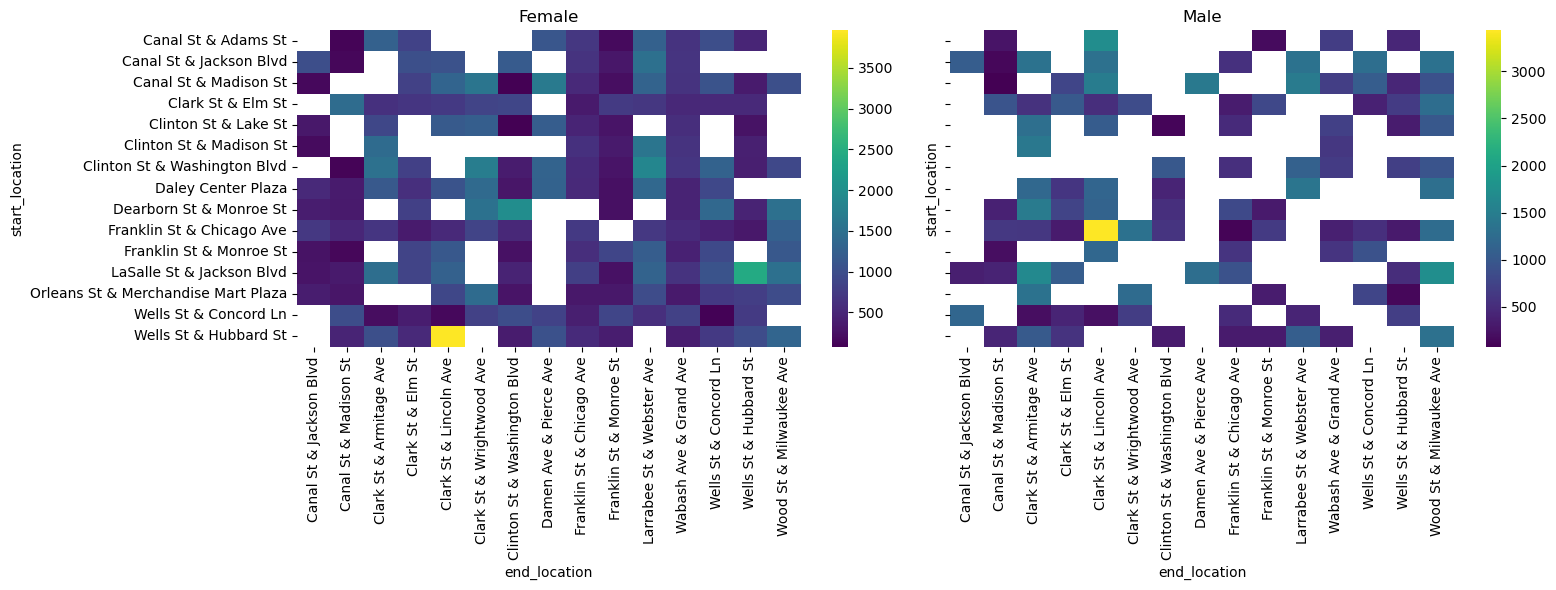

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# reduce size so plot is readable
top_starts = df['start_location'].value_counts().head(15).index
top_ends = df['end_location'].value_counts().head(15).index

df_small = df[
    df['start_location'].isin(top_starts) &
    df['end_location'].isin(top_ends)
]

genders = df_small['gender_label'].dropna().unique()

fig, axes = plt.subplots(1, len(genders), figsize=(16,6), sharey=True)

# handle case where only one gender exists
if len(genders) == 1:
    axes = [axes]

for ax, gender in zip(axes, genders):
    subset = df_small[df_small['gender_label'] == gender]
    
    pivot = subset.pivot(
        index='start_location',
        columns='end_location',
        values='avg_trip_duration'
    )
    
    sns.heatmap(pivot, cmap='viridis', ax=ax)
    ax.set_title(gender)

plt.tight_layout()
plt.show()

Research Question: Is there a difference in average trip duartion for each start and end location pair between male and female Divvy bike users? 

$H_0$: For any given start–end pair, males and females have the same average trip duration.
$H_a$: For at least some routes, males and females have different average trip durations.

In [12]:
pivot = df.pivot_table(
    index=['start_location','end_location'],
    columns='gender_label',
    values='avg_trip_duration'
).dropna()

diff = pivot['Female'] - pivot['Male']

from scipy.stats import ttest_1samp
t_stat, p_value = ttest_1samp(diff, 0)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: -9.233893720366977
p-value: 3.914775050097436e-20


/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Female', ylabel='Count'>

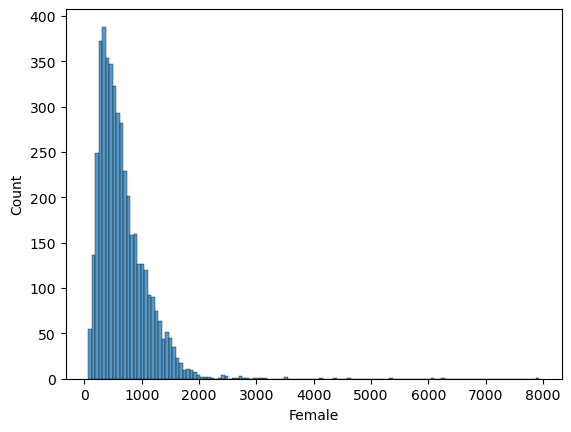

In [13]:
# Distribution of Female Avg trip duration
pivot['Female']
sns.histplot(pivot['Female'])

/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Male', ylabel='Count'>

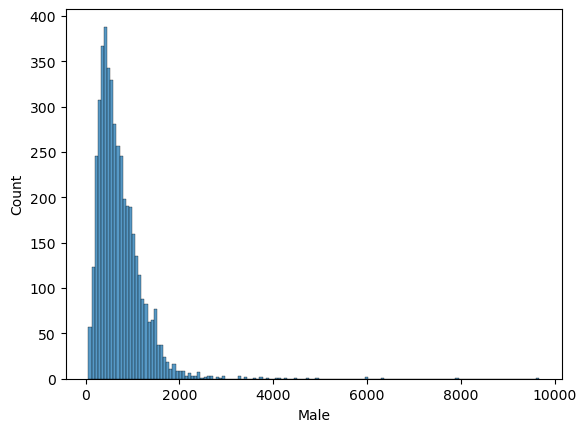

In [14]:
# Distribution of male trip duration
sns.histplot(pivot['Male'])

Conclusion: There is statistically significant evidence that for at least some routes in the data, males and females have different trip averages. 

Reasearch Question: Is gender a good predictor of the average time between specific stations in Chicago?

Research Question: Is user type (casual or member) a good predictor of the average time between specific stations in chicago?

Research Question: is the docking point capacity of the start station a good predictor of the average time between specific stations in Chicago? what about the end station?


In [15]:
import statsmodels.formula.api as smf

model = smf.ols(
    'avg_trip_duration ~ C(start_location) + C(end_location) + C(gender)',
    data=average_trip_gender
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_trip_duration   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     3.547
Date:                Sun, 03 May 2026   Prob (F-statistic):          6.49e-160
Time:                        16:23:25   Log-Likelihood:            -1.6279e+05
No. Observations:               21294   AIC:                         3.268e+05
Df Residuals:                   20686   BIC:                         3.316e+05
Df Model:                         607                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [16]:
from scipy.stats import f_oneway

groups = [
    group['avg_trip_duration'].values
    for _, group in df.groupby('gender_label')
]

f_stat, p_val = f_oneway(*groups)

In [17]:
p_val

4.9691218849573166e-09

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

df = average_trip_gender.copy()

# features + target
X = df[['start_location', 'end_location', 'gender']]
y = df['avg_trip_duration']

# preprocessing (encode categories)
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['start_location','end_location','gender'])
    ]
)

model = Pipeline([
    ('prep', preprocess),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("RMSE:", mean_squared_error(y_test, preds, squared=False))

RMSE: 507.40707044171154


In [19]:
df['avg_trip_duration'].mean()

816.430210693576

/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='avg_trip_duration', ylabel='Count'>

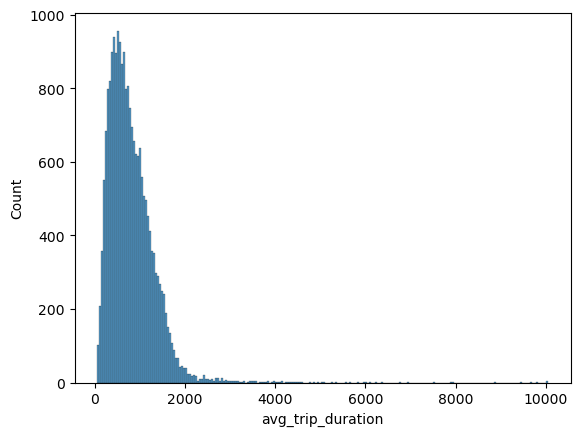

In [20]:
sns.histplot(df['avg_trip_duration'])

The mean trip time for each Only using start location, end location, and gender is not enough to predict the average trip duration between stations in Chicago.

In [21]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

In [22]:
df = average_trip.copy()
df['distance_km'] = haversine(
    df['start_lat'], df['start_lng'],
    df['end_lat'], df['end_lng']
)

In [23]:
import statsmodels.api as sm

X = df[['distance_km', 'gender', 'usertype', 'st_hour','start_dpcapactiy']]
X = sm.add_constant(X)
y = df['avg_trip_duration']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_trip_duration   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                 1.116e+04
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        16:24:01   Log-Likelihood:            -3.2344e+05
No. Observations:               44453   AIC:                         6.469e+05
Df Residuals:                   44448   BIC:                         6.469e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
distance_km        246.1172      1.172  

In [24]:
df['log_avg'] = np.log1p(df['avg_trip_duration'])

In [25]:

X = df[['distance_km', 'gender', 'usertype', 'st_hour',
        'start_dpcapactiy']]

X = sm.add_constant(X)
y = df['log_avg']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_avg   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                 1.784e+04
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        16:24:01   Log-Likelihood:                -23876.
No. Observations:               44453   AIC:                         4.776e+04
Df Residuals:                   44448   BIC:                         4.781e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
distance_km          0.3679      0.001  

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_log = model.predict(X)
pred = np.expm1(pred_log)

rmse = mean_squared_error(df['avg_trip_duration'], pred, squared=False)
mae = mean_absolute_error(df['avg_trip_duration'], pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 658.0493985106565
MAE: 206.28399669353206


In [27]:
fitted = model.fittedvalues
residuals = model.resid

/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


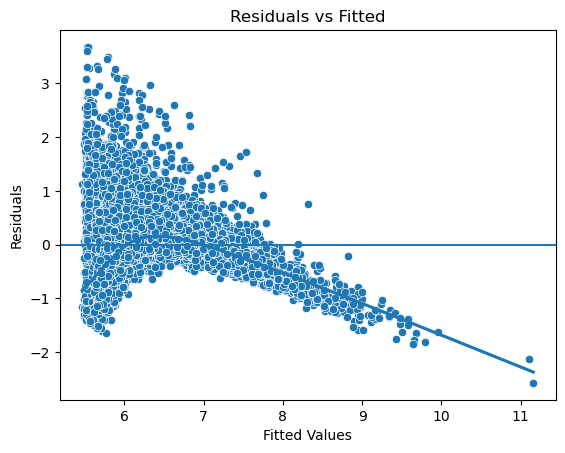

In [28]:
import matplotlib.pyplot as plt
plt.figure()
sns.scatterplot(x=fitted, y=residuals)
sns.regplot(x=fitted, y=residuals, scatter=False, lowess=True)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

The residuals versus fitted values plot reveals a clear pattern, indicating that the model does not fully capture the relationship between predictors and trip duration. Specifically, residuals decrease as fitted values increase, suggesting systematic bias. Additionally, the funnel-shaped distribution indicates heteroskedasticity, meaning that the variance of residuals is not constant. These patterns suggest that nonlinear relationships and interaction effects may be present and should be incorporated to improve model performance.

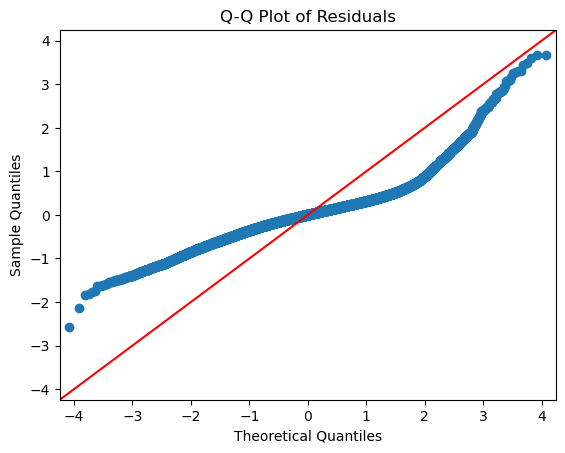

In [29]:
sm.qqplot(model.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

The Q–Q plot indicates deviations from normality, particularly in the tails, suggesting the presence of skewness and outliers. While transformations and nonlinear terms improved model fit, perfect normality was not achieved, which is expected given the variability in trip duration data. However, the model remains appropriate for predictive purposes.

In [30]:
df['log_distance'] = np.log1p(df['distance_km'])
df['distance_hour'] = df['distance_km'] * df['st_hour']
df['hour_group'] = pd.cut(df['st_hour'], bins=[0,6,12,18,24])
X = df[['distance_km','log_distance','distance_hour','gender','usertype','st_hour',
        'start_dpcapactiy']]

In [31]:
X = sm.add_constant(X)
y = df['log_avg']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_avg   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                 1.689e+04
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        16:24:41   Log-Likelihood:                -18759.
No. Observations:               44453   AIC:                         3.753e+04
Df Residuals:                   44446   BIC:                         3.759e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
distance_km         -0.0854      0.006  

In [32]:
fitted = model.fittedvalues
residuals = model.resid

/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ariderritt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


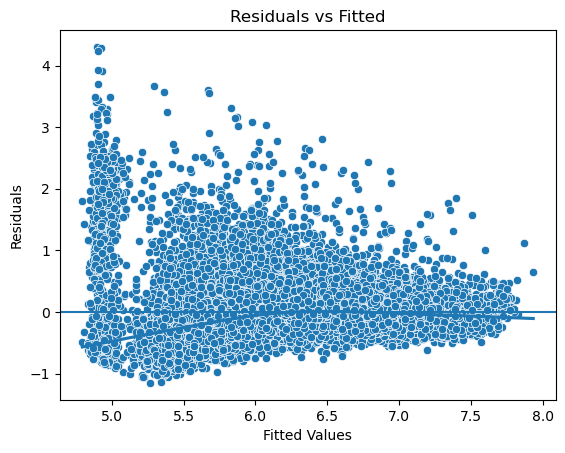

In [33]:
import matplotlib.pyplot as plt
plt.figure()
sns.scatterplot(x=fitted, y=residuals)
sns.regplot(x=fitted, y=residuals, scatter=False, lowess=True)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

The updated residuals versus fitted plot shows a substantial improvement compared to the initial model, with reduced curvature and bias. However, some heteroskedasticity and minor patterns remain, suggesting that while nonlinear effects have been partially addressed, additional complexity may still exist in the data

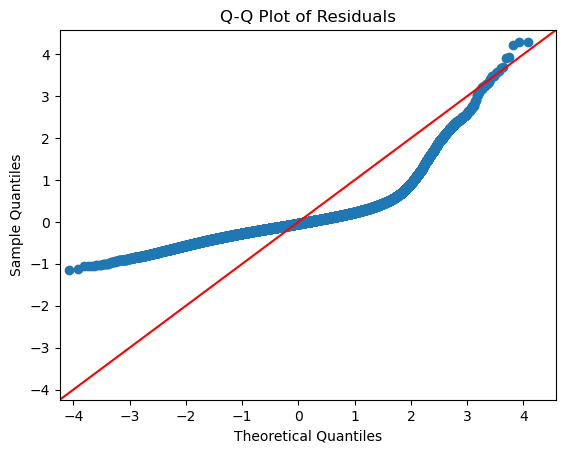

In [34]:
sm.qqplot(model.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [35]:
print(model.model.exog_names)

new_obs = pd.DataFrame({
    'distance_km': [2.5],
    'gender': [1],
    'usertype': [0],
    'st_hour': [14],
    'start_dpcapactiy': [15],
})

new_obs['log_distance'] = np.log1p(new_obs['distance_km'])
new_obs['distance_hour'] = new_obs['distance_km'] * new_obs['st_hour']
new_obs = sm.add_constant(new_obs)
new_obs = new_obs[model.model.exog_names]

pred = model.get_prediction(new_obs)
summary = pred.summary_frame(alpha=0.05)

['distance_km', 'log_distance', 'distance_hour', 'gender', 'usertype', 'st_hour', 'start_dpcapactiy']


In [36]:
pred = model.get_prediction(new_obs)
summary = pred.summary_frame(alpha=0.05)  # 95% interval
summary[['mean','obs_ci_lower','obs_ci_upper']] = np.expm1(
    summary[['mean','obs_ci_lower','obs_ci_upper']]
)

print(summary)

       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  6.133668  0.013003        1.93934       1.990311      2.459299   

   obs_ci_upper  
0     13.710846  


In [37]:
df = df.drop(columns=['end_dpcapactiy'])
df

,start_lat,start_lng,end_lat,end_lng,usertype,st_month,st_hour,ed_hour,gender,start_dpcapactiy,avg_trip_duration,distance_km,log_avg,log_distance,distance_hour,hour_group
0,41.896802,-87.635638,41.943340,-87.670970,1,3,16,16,0,22,1518.0,5.943384,7.325808,1.937789,95.094146,"(12, 18]"
1,41.865861,-87.646611,41.882242,-87.641066,1,3,17,17,0,15,531.0,1.878453,6.276643,1.057253,31.933708,"(12, 18]"
2,41.897764,-87.642884,41.894448,-87.622663,1,3,16,17,0,43,611.0,1.713801,6.416732,0.998350,27.420820,"(12, 18]"
3,41.878412,-87.641052,41.865212,-87.617759,1,3,7,8,0,50,968.5,2.423655,6.876780,1.230709,16.965588,"(6, 12]"
4,41.882091,-87.639833,41.893832,-87.634195,1,3,8,8,1,25,592.0,1.386453,6.385194,0.869808,11.091623,"(6, 12]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44448,41.893843,-87.641851,41.891738,-87.626937,1,4,17,17,1,23,537.0,1.256487,6.287859,0.813809,21.360280,"(12, 18]"
44449,41.862378,-87.651062,41.875933,-87.630585,1,4,6,6,0,15,793.0,2.268649,6.677083,1.184377,13.611897,"(0, 6]"
44450,41.913688,-87.652855,41.909592,-87.653497,1,3,20,20,0,15,176.0,0.458552,5.176150,0.377444,9.171043,"(18, 24]"
44451,41.920445,-87.663095,41.913688,-87.652855,1,4,13,13,1,15,334.0,1.132427,5.814131,0.757261,14.721547,"(12, 18]"


In [38]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

class TripAnalysis:

    def __init__(self, distance_km, gender, usertype, st_hour,
                 start_dpcapacity):
        self.distance_km = distance_km
        self.gender = gender
        self.usertype = usertype
        self.st_hour = st_hour
        self.start_dpcapacity = start_dpcapacity
        self.summary = None

    def prediction_interval(self):
        self.gender = self.gender.lower()
        if self.gender == 'm':
            gender_val = 1
        elif self.gender == 'f':
            gender_val = 0
        else:
            raise ValueError("Please enter valid gender (M/F)")

        self.usertype = self.usertype.lower()
        if self.usertype == 'c':
            usertype_val = 0
        elif self.usertype == 'm':
            usertype_val = 1
        else:
            raise ValueError("Please enter valid rider type (c/m)")


        new_obs = pd.DataFrame({
        'distance_km': [self.distance_km],
        'gender': [gender_val],
        'usertype': [usertype_val],
        'st_hour': [self.st_hour],
        'start_dpcapactiy': [self.start_dpcapacity]
        })

        new_obs['log_distance'] = np.log1p(new_obs['distance_km'])
        new_obs['distance_hour'] = new_obs['distance_km'] * new_obs['st_hour']
        new_obs = sm.add_constant(new_obs)
        new_obs = new_obs[model.model.exog_names]

        pred = model.get_prediction(new_obs)
        summary = pred.summary_frame(alpha=0.05)

   
        summary[['mean','obs_ci_lower','obs_ci_upper']] = np.expm1(
            summary[['mean','obs_ci_lower','obs_ci_upper']]
        )

        self.summary = summary

    def get_min(self):
        return self.summary['obs_ci_lower'].iloc[0]

    def get_max(self):
        return self.summary['obs_ci_upper'].iloc[0]

    def get_avg(self):
        return self.summary['mean'].iloc[0]

    def get_stats(self):
        return {
            "min": self.get_min(),
            "avg": self.get_avg(),
            "max": self.get_max()
        }

In [39]:
new_trip = TripAnalysis(2.5,'m','c',14,15)

In [40]:
new_trip.prediction_interval()
new_trip.get_stats()

{'min': 2.4592993095869335,
 'avg': 6.133668064499392,
 'max': 13.710846185939038}